In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
sys.path.append("../")

import evaluate
import checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Loss

Best Validation Loss: 0.041


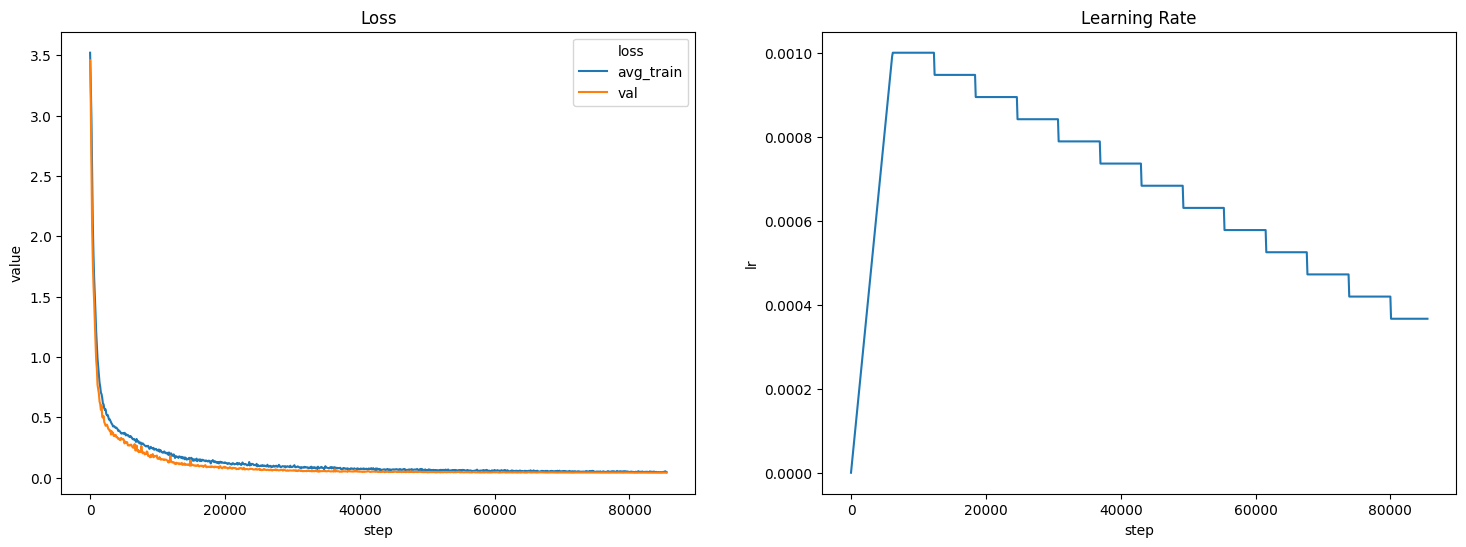

In [2]:
cp = checkpoint.CheckPoint("../models/MLC_data200k_nepoch20_best.pt", device=DEVICE)
fig, ax = plt.subplots(1, 2, figsize=(18,6))
ax[0] = cp.plot_loss(ax[0])
_ = ax[0].set_title("Loss")
ax[1] = cp.plot_learning_rate(ax[1])
_ = ax[1].set_title("Learning Rate")
print(f'Best Validation Loss: {cp.checkpoint["best_val_loss"]:.3f}')

### Accuracy

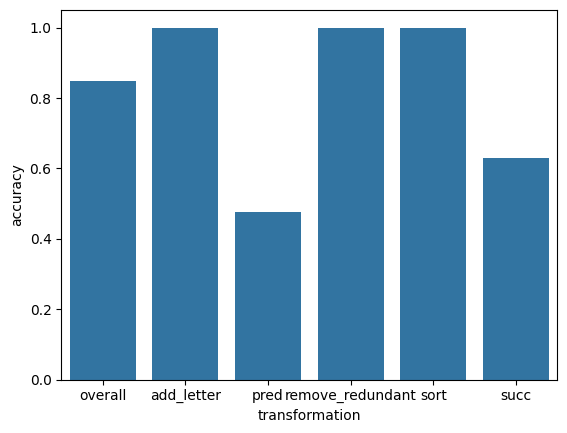

In [3]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["overall","add_letter","pred","remove_redundant","sort","succ"], var_name="transformation", value_name="accuracy")
_ = sns.barplot(val_acc[val_acc["epoch"]==13], x="transformation", y="accuracy")

Best Validation Accuracy: 0.849


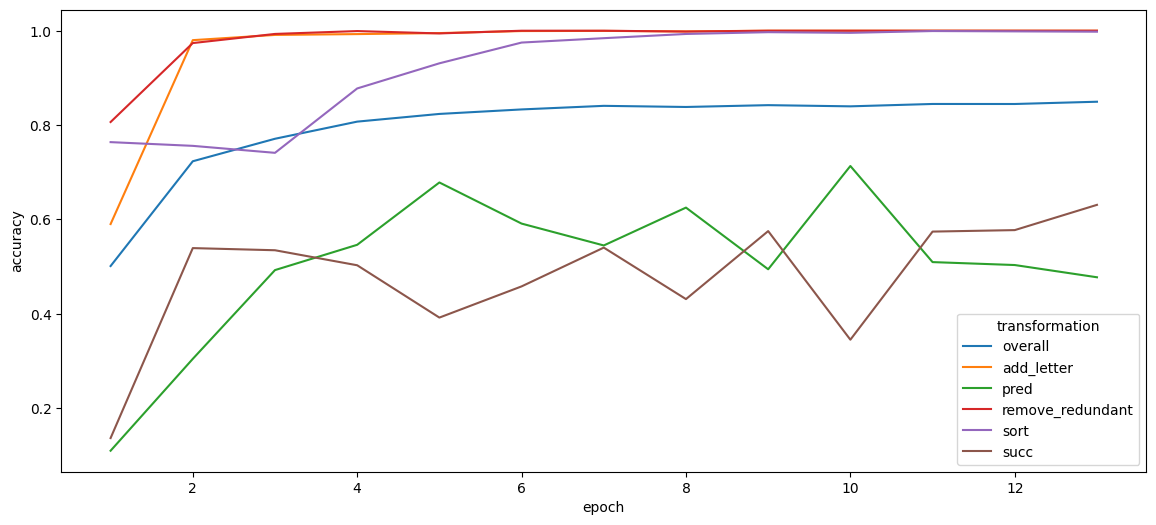

In [4]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["overall","add_letter","pred","remove_redundant","sort","succ"], var_name="transformation", value_name="accuracy")
print(f"Best Validation Accuracy: {val_acc.loc[val_acc["transformation"] =="overall","accuracy"].max():.3f}")
_ = plt.figure(figsize=(14,6))
_ = sns.lineplot(val_acc, x="epoch", y="accuracy", hue="transformation")

### Predictions

In [5]:
net = cp.load_model()
_, val = cp.load_dataloaders("../data")

Loading model that has completed (or started) 14 of 20 epochs
	batch size: 25
	number of steps:85,600
	best val loss achieved: 0.0410
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loading training (153,835 samples) and validation (17,093 samples) dataloaders.


In [6]:
batch = next(iter(val))
preds = evaluate.predict(batch, net, val.dataset.langs, 20, eval_type="max")
print("False Predictions:\n---------------------------------------------------------------------------------------")
for i in range(len(batch["yq"])):
    true = batch["yq"][i]
    pred = preds[i]
    if true != pred:
        print(f"Transformation type: {batch["transformation"][i]}")
        xq_context = " ".join(batch["xq_context"][i])
        xq_context = xq_context.replace("SOS", "|").replace("IO", "->")
        print(xq_context)
        print(f"True: {" ".join(true)}\t\tPredicted: {" ".join(pred)}\n")

False Predictions:
---------------------------------------------------------------------------------------
Transformation type: pred
a b s e x f h w i u k c g v o y z q l r j n m t d p | h w i u k -> f w i u k | c g v
True: k g v		Predicted: c g o

Transformation type: pred
a b c d r f g h i j k l m n o p q e s t u v w x y z | m n o -> l n o | f g h i j
True: r g h i j		Predicted: f g h i k

Transformation type: succ
a b c d r f g h i j k l m n o p q e s t u v w x y z | k l m n o p -> k l m n o q | j k
True: j l		Predicted: i k

Transformation type: succ
a b s e x f h w i u k c g v o y z q l r j n m t d p | l r j n -> l r j m | y z q l
True: y z q r		Predicted: o z q l

Transformation type: succ
a b c d r f g h i j k l m n o p q e s t u v w x y z | m n o p q -> m n o p e | r f g h i
True: r f g h j		Predicted: d f g h i

Transformation type: pred
a b c d e f g h i j k l m n o p q r s t u v w x y z | i j k -> h j k | m n o
True: l n o		Predicted: m n p

Transformation type: succ
a b c d